# 📊 PROYECTO FINAL – ANÁLISIS DE DATOS I
**Maestría en Ciencia de Datos**


## Clasificación Integral de Oficinas según Nivel de Vulnerabilidad


### 👥 Integrantes
**Andres Felipe Obando Certuch**  
**Daniela Arboleda Benavides**


## 1. 🎯 DESCRIPCIÓN DEL PROBLEMA

En la organización se cuenta con información relacionada con **Riesgo Psicosocial, Evaluación del Desempeño y Engagement** para diferentes oficinas y regionales. Estas dimensiones permiten observar aspectos importantes del entorno laboral, el desempeño de los colaboradores y su nivel de vinculación con la organización.

El principal problema es que esta información se encuentra distribuida en múltiples variables y periodos, lo que dificulta obtener una visión integral de cada oficina. Analizar cada indicador por separado puede hacer que se pierda la relación entre las diferentes dimensiones y que sea más difícil identificar cuáles oficinas requieren mayor atención.

Por esta razón, el proyecto busca **integrar los resultados de las tres dimensiones y clasificar las oficinas según su nivel de vulnerabilidad**. La clasificación propuesta contempla tres niveles: **alto, medio y bajo**, con el propósito de facilitar la priorización de acciones de seguimiento e intervención.

El impacto esperado es apoyar la toma de decisiones de Gestión Humana mediante una lectura más sencilla y objetiva de la información. De esta manera, las oficinas con señales de mayor vulnerabilidad podrán recibir una atención prioritaria, mientras que las oficinas con mejores resultados podrán identificarse como referentes de buenas prácticas.


## 2. 🗂️ Complejidad y disponibilidad de los datos

El conjunto de datos presenta una estructura de varias dimensiones y periodos históricos. Esto permite realizar un análisis más completo, pero también exige procesos de limpieza, transformación y selección de variables antes de aplicar técnicas de Ciencia de Datos.


### 2.1 Fuente y características del conjunto de datos


La información utilizada se encuentra consolidada en el archivo `Data_set.csv`. El conjunto inicial contiene **273 registros y 61 variables**.

Las variables incluyen información de identificación y ubicación de las unidades, resultados de Riesgo Psicosocial, Evaluación del Desempeño y Engagement.

En el caso de Riesgo Psicosocial se dispone de información para **2023 y 2025**, mientras que Evaluación del Desempeño contiene información histórica desde **2020 hasta 2025**. Para Engagement se cuenta con información correspondiente a **2025**.

La estructura general puede resumirse así:

| Dimensión | Periodos disponibles | Principales indicadores |
|---|---|---|
| Riesgo Psicosocial | 2023 y 2025 | Estrés, factores intralaborales y extralaborales |
| Evaluación del Desempeño | 2020 a 2025 | Objetivo, competencia y resultado |
| Engagement | 2025 | Ambiente laboral y compromiso |

### 2.2 Unidad de análisis


La unidad de análisis es la **oficina**. Cada registro representa una unidad identificada mediante variables como `CODIGO UNIDAD`, `TIPO` y `REGIONAL`.

Para el análisis se decidió trabajar únicamente con las unidades de tipo **Agencia** y **PDA**, debido a que son unidades operativas comparables y permiten una mejor interpretación para la clasificación.

Después de esta selección, la población de análisis queda conformada por **186 unidades operativas: 121 Agencias y 65 PDA**.

Las unidades de tipo **Dirección General** y **Regional** no se utilizan en la clusterización, ya que representan niveles organizacionales diferentes a las oficinas operativas.

### 2.3 Periodos disponibles


El conjunto de datos permite analizar diferentes horizontes temporales:

- **Riesgo Psicosocial:** 2023 y 2025.
- **Evaluación del Desempeño:** 2020, 2021, 2022, 2023, 2024 y 2025.
- **Engagement:** 2025.
- **APERTURA:** fecha de apertura de cada unidad, almacenada inicialmente como número serial de Excel.

La disponibilidad histórica del desempeño permite observar la evolución de esta dimensión, mientras que los indicadores de 2025 permiten construir una fotografía más reciente de la situación de las oficinas.

### 2.4 Variables disponibles


Las variables se pueden agrupar en cuatro grandes categorías:

1. **Identificación y ubicación:** `REGIONAL`, `CODIGO UNIDAD` y `TIPO`.
2. **Antigüedad o apertura:** `APERTURA`.
3. **Riesgo Psicosocial:** proporciones asociadas a niveles de riesgo muy alto, alto, medio, bajo y sin riesgo para estrés, factores intralaborales y extralaborales.
4. **Evaluación del Desempeño y Engagement:** indicadores numéricos e interpretaciones para las dimensiones disponibles.

Un aspecto importante es que varias variables fueron cargadas como texto aunque representan valores numéricos. Por ejemplo, algunos decimales utilizan coma como separador. Por esta razón, es necesario transformar estas variables antes de realizar cálculos estadísticos o construir modelos.

### 2.5 Calidad y limitaciones de los datos


Durante la revisión inicial se identificaron las siguientes características de calidad:

- El conjunto contiene **273 registros iniciales**, de los cuales **186 corresponden a Agencias y PDA** utilizadas para el análisis.
- Las variables de Riesgo Psicosocial presentan valores faltantes porque no todas las unidades cuentan con mediciones para estos indicadores. Para 2025 se observan **52 valores faltantes por variable**, mientras que para 2023 se observan **67**.
- En Evaluación del Desempeño existen algunos valores faltantes, especialmente en los años anteriores.
- Engagement 2025 presenta pocos valores faltantes en comparación con las demás dimensiones.
- Los datos numéricos requieren conversión desde texto a formato numérico.
- La variable `APERTURA` requiere conversión desde el formato serial de Excel a una fecha.

Estas condiciones hacen necesario realizar una etapa de limpieza y preparación antes del modelamiento. Además, la información disponible está agregada por oficina, por lo que no permite explicar directamente el comportamiento individual de cada colaborador.


## 3. 🤖 Justificación del uso de Ciencia de Datos e IA


El uso de Ciencia de Datos es pertinente porque el problema involucra **muchas variables, diferentes periodos y unidades que deben ser comparadas bajo criterios comunes**. Una revisión manual de todos los indicadores puede ser lenta y dificultar la identificación de patrones.

En este proyecto, las técnicas de análisis de datos permiten:

- Integrar diferentes dimensiones en una misma visión de la oficina.
- Transformar y estandarizar variables que están en escalas diferentes.
- Identificar patrones entre oficinas con características similares.
- Clasificar las unidades en grupos de vulnerabilidad.
- Facilitar la priorización de oficinas para seguimiento e intervención.

Como parte del proyecto se plantea utilizar **clusterización**, específicamente el algoritmo **K-Means**, para identificar grupos de oficinas con comportamientos similares en Riesgo Psicosocial, Desempeño y Engagement.

El enfoque es principalmente **no supervisado**, porque no se dispone de una variable objetivo que indique de manera directa si una oficina tuvo o no deserción de colaboradores. En lugar de entrenar un modelo predictivo de deserción, primero se busca descubrir estructuras y perfiles de vulnerabilidad presentes en los datos.

Posteriormente, estos perfiles pueden convertirse en una herramienta de apoyo para Gestión Humana: una oficina ubicada en un grupo de mayor vulnerabilidad podría recibir una intervención más inmediata, mientras que una oficina con resultados favorables podría utilizarse como referencia de buenas prácticas.

## 4. 🎯 Pregunta de análisis SMART


### 4.1 Pregunta SMART


> **¿Cómo podemos integrar los resultados de Riesgo Psicosocial, Evaluación del Desempeño y Engagement para clasificar las 186 unidades operativas (121 Agencias y 65 PDA) según su nivel de vulnerabilidad —alto, medio o bajo— y establecer una priorización de acciones de seguimiento e intervención al cierre del análisis?**

La pregunta cumple con el enfoque **SMART** porque:

- **Específica:** se concentra en tres dimensiones concretas y en las oficinas operativas.
- **Medible:** utiliza 186 unidades y tres niveles de clasificación: alto, medio y bajo.
- **Alcanzable:** se basa en información que ya se encuentra disponible en el conjunto de datos.
- **Relevante:** busca apoyar decisiones relacionadas con gestión del talento, seguimiento y retención.
- **Temporal:** la clasificación se realizará utilizando la información disponible y se evaluará al cierre del análisis del proyecto.

### 4.2 Objetivo general


**Integrar los resultados de Riesgo Psicosocial, Evaluación del Desempeño y Engagement para identificar patrones de comportamiento y clasificar las oficinas operativas según su nivel de vulnerabilidad, con el fin de facilitar la priorización de acciones de seguimiento e intervención.**


### 4.3 Objetivos específicos


1. **Explorar y preparar** la información de las Agencias y PDA, identificando valores faltantes, tipos de datos, variables relevantes y posibles limitaciones del conjunto de datos.

2. **Construir indicadores comparables** de Riesgo Psicosocial, Desempeño y Engagement que permitan representar de manera integral la situación de cada oficina.

3. **Aplicar una técnica de clusterización**, como K-Means, para identificar grupos de oficinas con características similares y posteriormente interpretar estos grupos como perfiles de vulnerabilidad.

4. **Definir una priorización de oficinas** según los resultados obtenidos, de manera que los grupos de mayor vulnerabilidad puedan orientar acciones de intervención y seguimiento.

5. **Generar una base para la toma de decisiones** en Gestión Humana, utilizando los resultados del análisis como apoyo para identificar alertas tempranas y oportunidades de mejora.

## 5. 🔎 Análisis Exploratorio de Datos

### 5.1 Carga de librerías y datos

En esta sección se realiza la carga de las librerías necesarias para la exploración, análisis y visualización del conjunto de datos. Posteriormente, se importa el archivo `Data_set.csv`, que contiene la información de las unidades analizadas y las variables relacionadas con Riesgo Psicosocial, Evaluación del Desempeño y Engagement.

In [1]:
# Librerías para manipulación y análisis de datos
import pandas as pd
import numpy as np

# Librerías para visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración para visualizar todas las columnas
pd.set_option('display.max_columns', None)

# Carga del conjunto de datos
df = pd.read_csv('../data/Data_set.csv', delimiter=';')

### 5.2 Exploración y calidad de los datos

In [2]:
# Información general del conjunto de datos
df.info()

# Visualización de los primeros registros
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 273 entries, 0 to 272
Data columns (total 61 columns):
 #   Column                                                      Non-Null Count  Dtype
---  ------                                                      --------------  -----
 0   REGIONAL                                                    273 non-null    str  
 1   CODIGO UNIDAD                                               273 non-null    str  
 2   TIPO                                                        273 non-null    str  
 3   APERTURA                                                    273 non-null    int64
 4   Riesgo psicosocial_AÑO 2025_ESTRÉS_Riesgo muy alto          221 non-null    str  
 5   Riesgo psicosocial_AÑO 2025_ESTRÉS_Riesgo alto              221 non-null    str  
 6   Riesgo psicosocial_AÑO 2025_ESTRÉS_Riesgo medio             221 non-null    str  
 7   Riesgo psicosocial_AÑO 2025_ESTRÉS_Riesgo bajo              221 non-null    str  
 8   Riesgo psicosocial_AÑO 2025_EST

,REGIONAL,CODIGO UNIDAD,TIPO,APERTURA,Riesgo psicosocial_AÑO 2025_ESTRÉS_Riesgo muy alto,Riesgo psicosocial_AÑO 2025_ESTRÉS_Riesgo alto,Riesgo psicosocial_AÑO 2025_ESTRÉS_Riesgo medio,Riesgo psicosocial_AÑO 2025_ESTRÉS_Riesgo bajo,Riesgo psicosocial_AÑO 2025_ESTRÉS_Sin riesgo,Riesgo psicosocial_AÑO 2025_INTRALABORALES_Riesgo muy alto,Riesgo psicosocial_AÑO 2025_INTRALABORALES_Riesgo alto,Riesgo psicosocial_AÑO 2025_INTRALABORALES_Riesgo medio,Riesgo psicosocial_AÑO 2025_INTRALABORALES_Riesgo bajo,Riesgo psicosocial_AÑO 2025_INTRALABORALES_Sin riesgo,Riesgo psicosocial_AÑO 2025_EXTRABORALES_Riesgo muy alto,Riesgo psicosocial_AÑO 2025_EXTRABORALES_Riesgo alto,Riesgo psicosocial_AÑO 2025_EXTRABORALES_Riesgo medio,Riesgo psicosocial_AÑO 2025_EXTRABORALES_Riesgo bajo,Riesgo psicosocial_AÑO 2025_EXTRABORALES_Sin riesgo,Riesgo psicosocial_AÑO 2023_ESTRÉS_Riesgo muy alto,Riesgo psicosocial_AÑO 2023_ESTRÉS_Riesgo alto,Riesgo psicosocial_AÑO 2023_ESTRÉS_Riesgo medio,Riesgo psicosocial_AÑO 2023_ESTRÉS_Riesgo bajo,Riesgo psicosocial_AÑO 2023_ESTRÉS_Sin riesgo,Riesgo psicosocial_AÑO 2023_INTRALABORALES_Riesgo muy alto,Riesgo psicosocial_AÑO 2023_INTRALABORALES_Riesgo alto,Riesgo psicosocial_AÑO 2023_INTRALABORALES_Riesgo medio,Riesgo psicosocial_AÑO 2023_INTRALABORALES_Riesgo bajo,Riesgo psicosocial_AÑO 2023_INTRALABORALES_Sin riesgo,Riesgo psicosocial_AÑO 2023_EXTRABORALES_Riesgo muy alto,Riesgo psicosocial_AÑO 2023_EXTRABORALES_Riesgo alto,Riesgo psicosocial_AÑO 2023_EXTRABORALES_Riesgo medio,Riesgo psicosocial_AÑO 2023_EXTRABORALES_Riesgo bajo,Riesgo psicosocial_AÑO 2023_EXTRABORALES_Sin riesgo,Evaluación del desempeño_AÑO 2025_OBJETIVO,Evaluación del desempeño_AÑO 2025_COMPETENCIA,Evaluación del desempeño_AÑO 2025_RESULTADO,Evaluación del desempeño_AÑO 2025_INTERPRETACION,Evaluación del desempeño_AÑO 2024_OBJETIVO,Evaluación del desempeño_AÑO 2024_COMPETENCIA,Evaluación del desempeño_AÑO 2024_RESULTADO,Evaluación del desempeño_AÑO 2024_INTERPRETACION,Evaluación del desempeño_AÑO 2023_OBJETIVO,Evaluación del desempeño_AÑO 2023_COMPETENCIA,Evaluación del desempeño_AÑO 2023_RESULTADO,Evaluación del desempeño_AÑO 2023_INTERPRETACION,Evaluación del desempeño_AÑO 2022_OBJETIVO,Evaluación del desempeño_AÑO 2022_COMPETENCIA,Evaluación del desempeño_AÑO 2022_RESULTADO,Evaluación del desempeño_AÑO 2022_INTERPRETACION,Evaluación del desempeño_AÑO 2021_OBJETIVO,Evaluación del desempeño_AÑO 2021_COMPETENCIA,Evaluación del desempeño_AÑO 2021_RESULTADO,Evaluación del desempeño_AÑO 2021_INTERPRETACION,Evaluación del desempeño_AÑO 2020_OBJETIVO,Evaluación del desempeño_AÑO 2020_COMPETENCIA,Evaluación del desempeño_AÑO 2020_RESULTADO,Evaluación del desempeño_AÑO 2020_INTERPRETACION,Engagement_AÑO 2025_AMBIENTE LABORAL,Engagement_AÑO 2025_COMPROMISO,Engagement_AÑO 2025_INTERPRETACION
0,CAUCA,A4112,Regional,42036,"0,315589354","0,247148289","0,216730038","0,106463878","0,114068441","0,133079848","0,201520913","0,258555133","0,220532319","0,186311787","0,197718631","0,212927757","0,25095057","0,140684411","0,197718631","0,162629758","0,186851211","0,242214533","0,155709343","0,252595156","0,093425606","0,173010381","0,211072664","0,249134948","0,273356401","0,162629758","0,186851211","0,242214533","0,155709343","0,252595156","0,897255455","0,885714286","0,893793104",Alto,"0,6435","0,838055556","0,70782",Medio,"0,699578571","0,844571429","0,743076429",Medio,"0,837","0,8668","0,84594",Alto,"0,90875","0,882986111","0,895868056",Alto,"0,8515","0,859861111","0,855680556",Alto,"0,963690476",1,Muy alto
1,CAUCA,A411243,PDA,39539,"0,222222222","0,222222222","0,333333333","0,222222222",0,"0,222222222","0,222222222","0,333333333","0,111111111","0,111111111","0,111111111","0,222222222","0,555555556","0,111111111",0,"0,363636364","0,181818182",0,"0,272727273","0,181818182","0,090909091","0,090909091","0,181818182","0,454545455","0,181818182","0,181818182","0,090909091","0,363636364","0,363636364",0,"0,807467273","0,847272727","0,819408909",Alto,"0,623636364","0,8391414

In [3]:
# Validar el numero de filas y columnas del DataFrame
df.shape

(273, 61)

#### 5.2.1 Validación de valores faltantes y selección de unidades de análisis

Se realiza una revisión inicial de los valores faltantes del conjunto de datos para identificar posibles limitaciones en la información disponible. Para garantizar la comparabilidad entre las unidades analizadas y considerando la disponibilidad de información en las dimensiones de Riesgo Psicosocial, Desempeño y Engagement, el análisis se concentrará en las unidades de tipo **Agencia** y **PDA**. Las unidades correspondientes a **Dirección General** y **Regional** se excluyen del análisis de clusterización.

In [4]:
# Distribución de unidades por tipo
df['TIPO'].value_counts()

TIPO
Agencia              121
Dirección general     74
PDA                   65
Regional              13
Name: count, dtype: int64

In [5]:
# Validación de valores faltantes
resumen_nulos = pd.DataFrame({
    'Valores faltantes': df.isna().sum(),
    'Porcentaje (%)': (df.isna().mean() * 100).round(2)
})

resumen_nulos[resumen_nulos['Valores faltantes'] > 0].sort_values(
    'Porcentaje (%)',
    ascending=False
)

,Valores faltantes,Porcentaje (%)
Riesgo psicosocial_AÑO 2023_EXTRABORALES_Riesgo alto,67,24.54
Riesgo psicosocial_AÑO 2023_ESTRÉS_Riesgo alto,67,24.54
Riesgo psicosocial_AÑO 2023_EXTRABORALES_Sin riesgo,67,24.54
Riesgo psicosocial_AÑO 2023_EXTRABORALES_Riesgo bajo,67,24.54
Riesgo psicosocial_AÑO 2023_EXTRABORALES_Riesgo medio,67,24.54
Riesgo psicosocial_AÑO 2023_EXTRABORALES_Riesgo muy alto,67,24.54
Riesgo psicosocial_AÑO 2023_INTRALABORALES_Sin riesgo,67,24.54
Riesgo psicosocial_AÑO 2023_INTRALABORALES_Riesgo bajo,67,24.54
Riesgo psicosocial_AÑO 2023_INTRALABORALES_Riesgo medio,67,24.54
Riesgo psicosocial_AÑO 2023_INTRALABORALES_Riesgo alto,67,24.54


In [6]:
# Seleccionar únicamente Agencias y PDA
df_modelo = df[df['TIPO'].isin(['Agencia', 'PDA'])].copy()

# Verificar dimensiones
print(f"Registros iniciales: {len(df)}")
print(f"Registros para el análisis: {len(df_modelo)}")

print("\nDistribución de unidades:")
print(df_modelo['TIPO'].value_counts())

print ("----" * 20)
# Verificar tipos incluidos en el dataset de análisis
df_modelo['TIPO'].unique()

Registros iniciales: 273
Registros para el análisis: 186

Distribución de unidades:
TIPO
Agencia    121
PDA         65
Name: count, dtype: int64
--------------------------------------------------------------------------------


<StringArray>
['PDA', 'Agencia']
Length: 2, dtype: str

### 5.3 Transformación y ajuste de tipos de datos


Durante la exploración inicial se identificó que varias variables cuantitativas fueron cargadas como texto (`string`), a pesar de contener valores numéricos. Esto se debe principalmente al formato utilizado para representar los decimales. También se identificó que la variable `APERTURA` corresponde a una fecha almacenada como número serial de Excel. Se realizará la conversión de estas variables a sus tipos de datos correspondientes, manteniendo como variables categóricas aquellas que representan identificadores, tipos de unidad, regionales e interpretaciones.

In [7]:
# Variables que deben permanecer como categóricas
variables_categoricas = [
    'REGIONAL',
    'CODIGO UNIDAD',
    'TIPO'
]

# Variables de interpretación
variables_interpretacion = [
    col for col in df.columns 
    if 'INTERPRETACION' in col
]

variables_categoricas = variables_categoricas + variables_interpretacion

# Variables candidatas a conversión numérica
variables_numericas = [
    col for col in df.columns 
    if col not in variables_categoricas + ['APERTURA']
]

len(variables_numericas)

# Convertir variables numéricas de texto a formato numérico
for col in variables_numericas:
    df_modelo[col] = pd.to_numeric(
        df[col].astype(str).str.replace(',', '.', regex=False),
        errors='coerce'
    )

# Convertir APERTURA de número serial de Excel a fecha
df_modelo['APERTURA'] = pd.to_datetime(
    df_modelo['APERTURA'],
    unit='D',
    origin='1899-12-30'
)
    
# Información general del conjunto de datos
df_modelo.info()

# Visualización de los primeros registros
df_modelo.head()

<class 'pandas.DataFrame'>
Index: 186 entries, 1 to 272
Data columns (total 61 columns):
 #   Column                                                      Non-Null Count  Dtype        
---  ------                                                      --------------  -----        
 0   REGIONAL                                                    186 non-null    str          
 1   CODIGO UNIDAD                                               186 non-null    str          
 2   TIPO                                                        186 non-null    str          
 3   APERTURA                                                    186 non-null    datetime64[s]
 4   Riesgo psicosocial_AÑO 2025_ESTRÉS_Riesgo muy alto          186 non-null    float64      
 5   Riesgo psicosocial_AÑO 2025_ESTRÉS_Riesgo alto              186 non-null    float64      
 6   Riesgo psicosocial_AÑO 2025_ESTRÉS_Riesgo medio             186 non-null    float64      
 7   Riesgo psicosocial_AÑO 2025_ESTRÉS_Riesgo bajo     

,REGIONAL,CODIGO UNIDAD,TIPO,APERTURA,Riesgo psicosocial_AÑO 2025_ESTRÉS_Riesgo muy alto,Riesgo psicosocial_AÑO 2025_ESTRÉS_Riesgo alto,Riesgo psicosocial_AÑO 2025_ESTRÉS_Riesgo medio,Riesgo psicosocial_AÑO 2025_ESTRÉS_Riesgo bajo,Riesgo psicosocial_AÑO 2025_ESTRÉS_Sin riesgo,Riesgo psicosocial_AÑO 2025_INTRALABORALES_Riesgo muy alto,Riesgo psicosocial_AÑO 2025_INTRALABORALES_Riesgo alto,Riesgo psicosocial_AÑO 2025_INTRALABORALES_Riesgo medio,Riesgo psicosocial_AÑO 2025_INTRALABORALES_Riesgo bajo,Riesgo psicosocial_AÑO 2025_INTRALABORALES_Sin riesgo,Riesgo psicosocial_AÑO 2025_EXTRABORALES_Riesgo muy alto,Riesgo psicosocial_AÑO 2025_EXTRABORALES_Riesgo alto,Riesgo psicosocial_AÑO 2025_EXTRABORALES_Riesgo medio,Riesgo psicosocial_AÑO 2025_EXTRABORALES_Riesgo bajo,Riesgo psicosocial_AÑO 2025_EXTRABORALES_Sin riesgo,Riesgo psicosocial_AÑO 2023_ESTRÉS_Riesgo muy alto,Riesgo psicosocial_AÑO 2023_ESTRÉS_Riesgo alto,Riesgo psicosocial_AÑO 2023_ESTRÉS_Riesgo medio,Riesgo psicosocial_AÑO 2023_ESTRÉS_Riesgo bajo,Riesgo psicosocial_AÑO 2023_ESTRÉS_Sin riesgo,Riesgo psicosocial_AÑO 2023_INTRALABORALES_Riesgo muy alto,Riesgo psicosocial_AÑO 2023_INTRALABORALES_Riesgo alto,Riesgo psicosocial_AÑO 2023_INTRALABORALES_Riesgo medio,Riesgo psicosocial_AÑO 2023_INTRALABORALES_Riesgo bajo,Riesgo psicosocial_AÑO 2023_INTRALABORALES_Sin riesgo,Riesgo psicosocial_AÑO 2023_EXTRABORALES_Riesgo muy alto,Riesgo psicosocial_AÑO 2023_EXTRABORALES_Riesgo alto,Riesgo psicosocial_AÑO 2023_EXTRABORALES_Riesgo medio,Riesgo psicosocial_AÑO 2023_EXTRABORALES_Riesgo bajo,Riesgo psicosocial_AÑO 2023_EXTRABORALES_Sin riesgo,Evaluación del desempeño_AÑO 2025_OBJETIVO,Evaluación del desempeño_AÑO 2025_COMPETENCIA,Evaluación del desempeño_AÑO 2025_RESULTADO,Evaluación del desempeño_AÑO 2025_INTERPRETACION,Evaluación del desempeño_AÑO 2024_OBJETIVO,Evaluación del desempeño_AÑO 2024_COMPETENCIA,Evaluación del desempeño_AÑO 2024_RESULTADO,Evaluación del desempeño_AÑO 2024_INTERPRETACION,Evaluación del desempeño_AÑO 2023_OBJETIVO,Evaluación del desempeño_AÑO 2023_COMPETENCIA,Evaluación del desempeño_AÑO 2023_RESULTADO,Evaluación del desempeño_AÑO 2023_INTERPRETACION,Evaluación del desempeño_AÑO 2022_OBJETIVO,Evaluación del desempeño_AÑO 2022_COMPETENCIA,Evaluación del desempeño_AÑO 2022_RESULTADO,Evaluación del desempeño_AÑO 2022_INTERPRETACION,Evaluación del desempeño_AÑO 2021_OBJETIVO,Evaluación del desempeño_AÑO 2021_COMPETENCIA,Evaluación del desempeño_AÑO 2021_RESULTADO,Evaluación del desempeño_AÑO 2021_INTERPRETACION,Evaluación del desempeño_AÑO 2020_OBJETIVO,Evaluación del desempeño_AÑO 2020_COMPETENCIA,Evaluación del desempeño_AÑO 2020_RESULTADO,Evaluación del desempeño_AÑO 2020_INTERPRETACION,Engagement_AÑO 2025_AMBIENTE LABORAL,Engagement_AÑO 2025_COMPROMISO,Engagement_AÑO 2025_INTERPRETACION
1,CAUCA,A411243,PDA,2008-04-01,0.222222,0.222222,0.333333,0.222222,0.000000,0.222222,0.222222,0.333333,0.111111,0.111111,0.111111,0.222222,0.555556,0.111111,0.000000,0.363636,0.181818,0.000000,0.272727,0.181818,0.090909,0.090909,0.181818,0.454545,0.181818,0.181818,0.090909,0.363636,0.363636,0.000000,0.807467,0.847273,0.819409,Alto,0.623636,0.839141,0.694909,Medio,0.724494,0.864800,0.765886,Alto,0.671466,0.809636,0.712917,Medio,0.854167,0.865509,0.859838,Alto,0.841818,0.864646,0.853232,Alto,0.840530,0.867424,Medio
2,CAUCA,A411242,PDA,2009-08-01,0.444444,0.333333,0.222222,0.000000,0.000000,0.222222,0.222222,0.111111,0.444444,0.000000,0.111111,0.333333,0.333333,0.000000,0.222222,0.416667,0.166667,0.166667,0.250000,0.000000,0.083333,0.333333,0.333333,0.166667,0.083333,0.250000,0.250000,0.083333,0.166667,0.250000,0.835373,0.865455,0.844397,Alto,0.676417,0.833333,0.723842,Medio,0.707672,0.855636,0.751816,Alto,0.856690,0.788167,0.836133,Alto,0.832500,0.833912,0.833206,Alto,0.943333,0.934606,0.938970,Muy alto,0.843403,0.892361,Medio
3,CAUCA,A411221,PDA,2019-07-15,0.333333,0.166667,0.500000,0.000000,0.000000,0.000000,0.000000,0.666667,0.166667,0.166667,0.000000,0.666667,0.333333,0.00

In [8]:
# Validar el numero de filas y columnas del DataFrame
df_modelo.shape

(186, 61)

**Resumen:** Se identificaron valores faltantes en algunas variables, principalmente asociados a unidades que no cuentan con determinadas mediciones. Para garantizar la comparabilidad de las unidades y reducir el impacto de la ausencia de información, se definió como población de análisis las **186 unidades operativas correspondientes a 121 Agencias y 65 PDA**. Estas unidades serán utilizadas posteriormente en el análisis exploratorio y en el modelo de clusterización.

### 5.4 Reducción y análisis de variables categóricas y numéricas

Se realiza una caracterización general de las variables del conjunto de datos, diferenciando entre variables categóricas y numéricas. Este análisis permite conocer la distribución de las principales variables y establecer una base para la selección de los indicadores que posteriormente serán utilizados en el modelo de clusterización. 

Adicionalmente se realizará la identificación de relaciones y posibles redundancias entre las variables que representan las dimensiones de Riesgo Psicosocial, Evaluación del Desempeño y Engagement. A partir de este análisis se definirán grupos de variables y criterios para construir indicadores representativos que reduzcan la dimensionalidad del conjunto de datos y faciliten posteriormente el proceso de clusterización.

In [9]:
# Identificar variables categóricas y numéricas
variables_categoricas = df_modelo.select_dtypes(include=['object', 'category']).columns.tolist()
variables_numericas = df_modelo.select_dtypes(include=['number']).columns.tolist()

print(f"Variables categóricas: {len(variables_categoricas)}")
print(f"Variables numéricas: {len(variables_numericas)}")

print("----" * 20)

print("Variables categóricas:")
for variable in variables_categoricas:
    print(f"- {variable}")

print("\nVariables numéricas:")
for variable in variables_numericas:
    print(f"- {variable}")


Variables categóricas: 10
Variables numéricas: 50
--------------------------------------------------------------------------------
Variables categóricas:
- REGIONAL
- CODIGO UNIDAD
- TIPO
- Evaluación del desempeño_AÑO 2025_INTERPRETACION
- Evaluación del desempeño_AÑO 2024_INTERPRETACION
- Evaluación del desempeño_AÑO 2023_INTERPRETACION
- Evaluación del desempeño_AÑO 2022_INTERPRETACION
- Evaluación del desempeño_AÑO 2021_INTERPRETACION
- Evaluación del desempeño_AÑO 2020_INTERPRETACION
- Engagement_AÑO 2025_INTERPRETACION

Variables numéricas:
- Riesgo psicosocial_AÑO 2025_ESTRÉS_Riesgo muy alto
- Riesgo psicosocial_AÑO 2025_ESTRÉS_Riesgo alto
- Riesgo psicosocial_AÑO 2025_ESTRÉS_Riesgo medio
- Riesgo psicosocial_AÑO 2025_ESTRÉS_Riesgo bajo
- Riesgo psicosocial_AÑO 2025_ESTRÉS_Sin riesgo
- Riesgo psicosocial_AÑO 2025_INTRALABORALES_Riesgo muy alto
- Riesgo psicosocial_AÑO 2025_INTRALABORALES_Riesgo alto
- Riesgo psicosocial_AÑO 2025_INTRALABORALES_Riesgo medio
- Riesgo psicosocial_A

/var/folders/d1/vp_8rlj93sj1jh8674v71pww0000gn/T/ipykernel_7798/1185270705.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  variables_categoricas = df_modelo.select_dtypes(include=['object', 'category']).columns.tolist()


In [10]:
# Resumen de variables numéricas
resumen_numericas = pd.DataFrame({
    'Variable': variables_numericas,
    'Mínimo': df_modelo[variables_numericas].min().values,
    'Máximo': df_modelo[variables_numericas].max().values,
    'Media': df_modelo[variables_numericas].mean().values,
    'Mediana': df_modelo[variables_numericas].median().values,
    'Valores faltantes': df_modelo[variables_numericas].isna().sum().values
})

resumen_numericas

,Variable,Mínimo,Máximo,Media,Mediana,Valores faltantes
0,Riesgo psicosocial_AÑO 2025_ESTRÉS_Riesgo muy ...,0.000000,0.750000,0.301177,0.300000,0
1,Riesgo psicosocial_AÑO 2025_ESTRÉS_Riesgo alto,0.000000,0.500000,0.201255,0.200000,0
2,Riesgo psicosocial_AÑO 2025_ESTRÉS_Riesgo medio,0.000000,0.600000,0.168790,0.155048,0
3,Riesgo psicosocial_AÑO 2025_ESTRÉS_Riesgo bajo,0.000000,0.571429,0.172006,0.153846,0
4,Riesgo psicosocial_AÑO 2025_ESTRÉS_Sin riesgo,0.000000,0.615385,0.156772,0.142857,0
5,Riesgo psicosocial_AÑO 2025_INTRALABORALES_Rie...,0.000000,0.625000,0.158916,0.142857,0
6,Riesgo psicosocial_AÑO 2025_INTRALABORALES_Rie...,0.000000,0.555556,0.186881,0.179144,0
7,Riesgo psicosocial_AÑO 2025_INTRALABORALES_Rie...,0.000000,0.750000,0.209583,0.200000,0
8,Riesgo psicosocial_AÑO 2025_INTRALABORALES_Rie...,0.000000,0.666667,0.210308,0.200000,0
9,Riesgo psicosocial_AÑO 2025_INTRALABORALES_Sin...,0.000000,0.666667,0.234312,0.200000,0


#### 5.4.1 Caracterización de variables

Se identifican las variables numéricas disponibles y se agrupan inicialmente de acuerdo con la dimensión y el concepto que representan. Esta clasificación permitirá diferenciar las variables asociadas a Riesgo Psicosocial, Evaluación del Desempeño y Engagement, y servirá como base para el análisis de correlaciones y la posterior construcción de indicadores.

In [11]:
# Identificar variables de Riesgo Psicosocial
variables_psicosocial = [
    col for col in df_modelo.columns
    if 'Riesgo psicosocial' in col
]

# Identificar variables de Evaluación del Desempeño
variables_desempeno = [
    col for col in df_modelo.columns
    if any(palabra in col.upper() for palabra in [
        'OBJETIVO',
        'COMPETENCIA',
        'RESULTADO'
    ])
]

# Identificar variables numéricas de Engagement
variables_engagement = [
    col for col in df_modelo.columns
    if 'Engagement' in col
    and 'INTERPRETACION' not in col.upper()
]

print(f"Variables de Riesgo Psicosocial: {len(variables_psicosocial)}")
print(f"Variables de Desempeño: {len(variables_desempeno)}")
print(f"Variables de Engagement: {len(variables_engagement)}")

print ("----"*20)

# Crear resumen de variables por dimensión
resumen_dimensiones = pd.DataFrame({
    'Dimensión': (
        ['Riesgo Psicosocial'] * len(variables_psicosocial) +
        ['Desempeño'] * len(variables_desempeno) +
        ['Engagement'] * len(variables_engagement)
    ),
    'Variable': (
        variables_psicosocial +
        variables_desempeno +
        variables_engagement
    )
})

resumen_dimensiones

Variables de Riesgo Psicosocial: 30
Variables de Desempeño: 18
Variables de Engagement: 2
--------------------------------------------------------------------------------


,Dimensión,Variable
0,Riesgo Psicosocial,Riesgo psicosocial_AÑO 2025_ESTRÉS_Riesgo muy ...
1,Riesgo Psicosocial,Riesgo psicosocial_AÑO 2025_ESTRÉS_Riesgo alto
2,Riesgo Psicosocial,Riesgo psicosocial_AÑO 2025_ESTRÉS_Riesgo medio
3,Riesgo Psicosocial,Riesgo psicosocial_AÑO 2025_ESTRÉS_Riesgo bajo
4,Riesgo Psicosocial,Riesgo psicosocial_AÑO 2025_ESTRÉS_Sin riesgo
5,Riesgo Psicosocial,Riesgo psicosocial_AÑO 2025_INTRALABORALES_Rie...
6,Riesgo Psicosocial,Riesgo psicosocial_AÑO 2025_INTRALABORALES_Rie...
7,Riesgo Psicosocial,Riesgo psicosocial_AÑO 2025_INTRALABORALES_Rie...
8,Riesgo Psicosocial,Riesgo psicosocial_AÑO 2025_INTRALABORALES_Rie...
9,Riesgo Psicosocial,Riesgo psicosocial_AÑO 2025_INTRALABORALES_Sin...


#### 5.4.2 Análisis de correlaciones

Se analiza la correlación entre las variables numéricas con el propósito de identificar relaciones fuertes y posibles redundancias. La correlación permitirá determinar qué variables presentan comportamientos similares y orientar la construcción de indicadores representativos para cada dimensión.

Variables numéricas analizadas: 20
--------------------------------------------------------------------------------


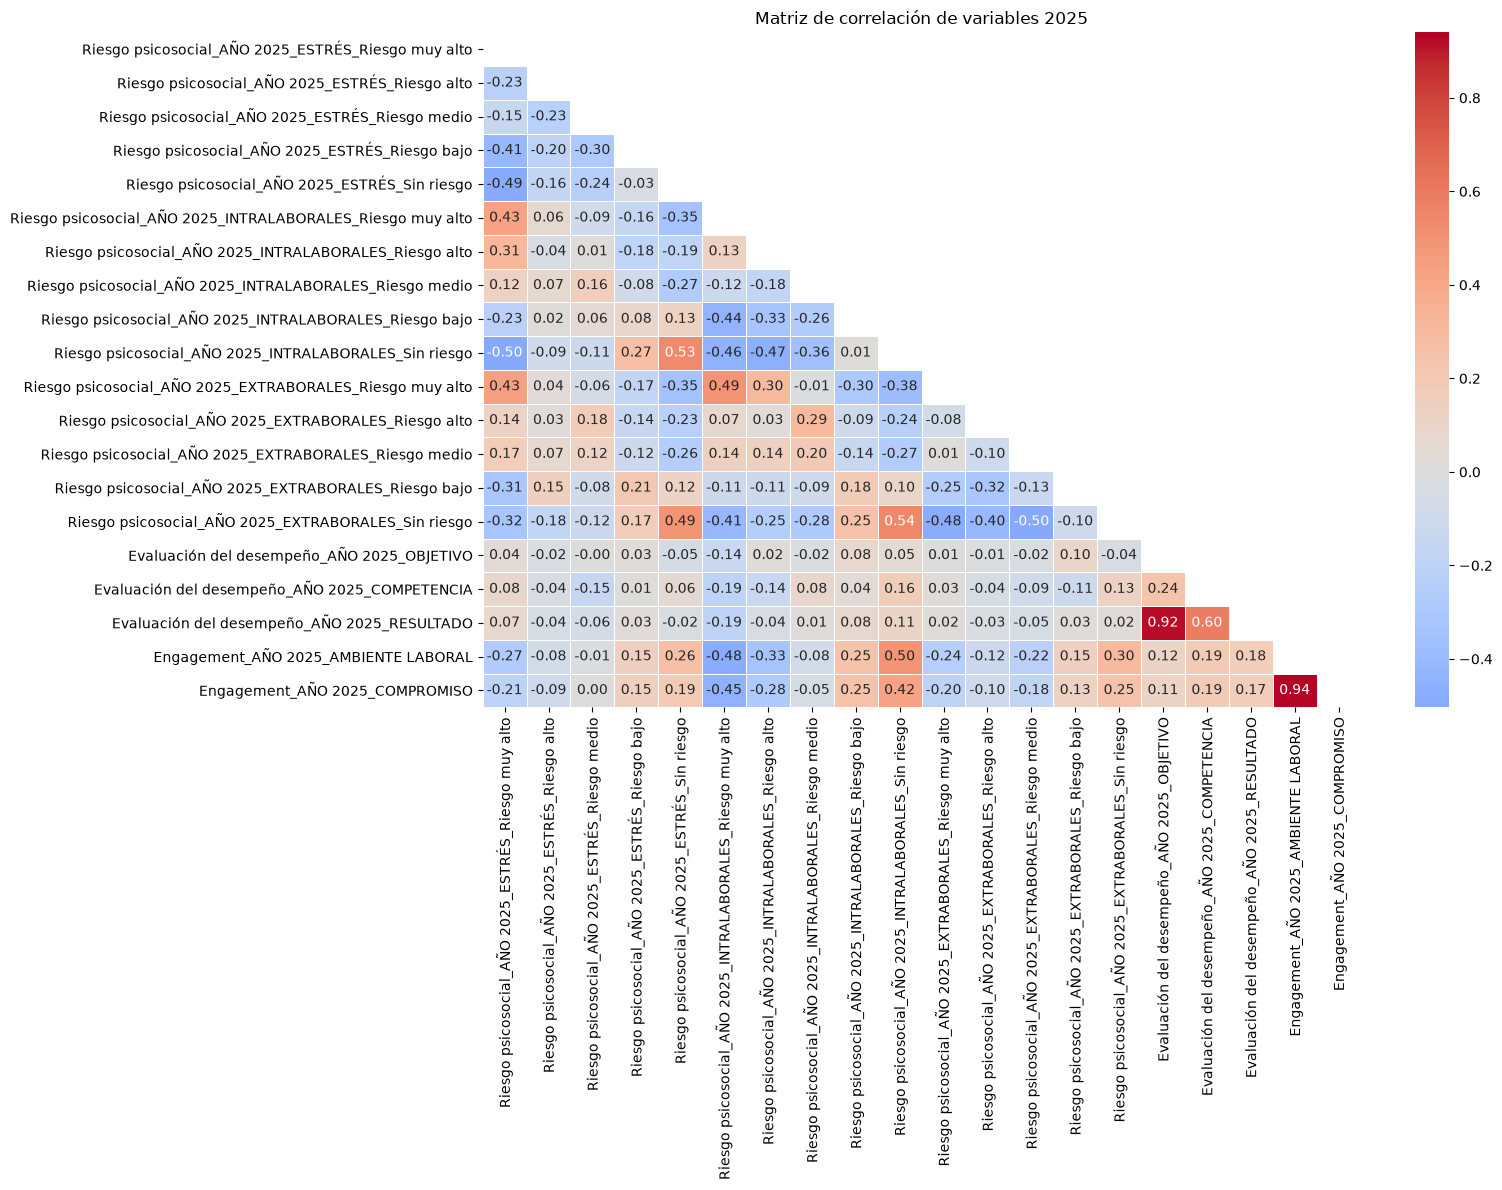

In [12]:
# Seleccionar variables numéricas correspondientes a 2025
variables_2025 = [
    col for col in variables_psicosocial + variables_desempeno + variables_engagement
    if '2025' in col
]

print(f"Variables numéricas analizadas: {len(variables_2025)}")

print ("----"*20)

# Matriz de correlación
matriz_correlacion = df_modelo[variables_2025].corr()

# Crear máscara para ocultar la mitad superior
mask = np.triu(np.ones_like(matriz_correlacion, dtype=bool))

# Visualización de la matriz de correlación
plt.figure(figsize=(16, 12))

sns.heatmap(
    matriz_correlacion,
    mask=mask,
    cmap='coolwarm',
    center=0,
    linewidths=0.5,
    annot=True,
    fmt='.2f'
)

plt.title('Matriz de correlación de variables 2025')
plt.tight_layout()
plt.show()

In [13]:
# Obtener pares de variables con correlaciones fuertes

correlaciones = (
    matriz_correlacion
    .where(np.triu(np.ones(matriz_correlacion.shape), k=1).astype(bool))
    .stack()
    .reset_index()
)

correlaciones.columns = ['Variable 1', 'Variable 2', 'Correlación']

correlaciones[
    correlaciones['Correlación'].abs() >= 0.70
].sort_values(
    'Correlación',
    key=abs,
    ascending=False
)

,Variable 1,Variable 2,Correlación
379,Engagement_AÑO 2025_AMBIENTE LABORAL,Engagement_AÑO 2025_COMPROMISO,0.940170
317,Evaluación del desempeño_AÑO 2025_OBJETIVO,Evaluación del desempeño_AÑO 2025_RESULTADO,0.919326


#### 5.4.3 Definición de grupos de variables

A partir de la revisión de las variables y sus relaciones, se establecen grupos conceptuales que representan las principales dimensiones del análisis. La agrupación busca reducir la cantidad de variables utilizadas posteriormente en el modelamiento, evitando que múltiples variables que representan un mismo fenómeno tengan un peso excesivo en el algoritmo de clusterización.

Los grupos iniciales serán:

- **Riesgo Psicosocial:** Estrés, factores intralaborales y factores extralaborales.
- **Evaluación del Desempeño:** Objetivo, Competencia y Resultado.
- **Engagement:** Ambiente Laboral y Compromiso.

Estos grupos servirán como base para la construcción de indicadores representativos de cada dimensión.

In [14]:
# Agrupación conceptual de variables
grupos_variables = {
    'Estres': [
        col for col in variables_2025
        if 'ESTRÉS' in col
    ],
    
    'Intralaboral': [
        col for col in variables_2025
        if 'INTRALABORALES' in col
    ],
    
    'Extralaboral': [
        col for col in variables_2025
        if 'EXTRABORALES' in col
    ],
    
    'Desempeño Objetivo': [
        col for col in variables_2025
        if 'OBJETIVO' in col
    ],
    
    'Desempeño Competencia': [
        col for col in variables_2025
        if 'COMPETENCIA' in col
    ],
    
    'Desempeño Resultado': [
        col for col in variables_2025
        if 'RESULTADO' in col
    ],
    
    'Engagement Ambiente Laboral': [
        col for col in variables_2025
        if 'AMBIENTE LABORAL' in col
    ],
    
    'Engagement Compromiso': [
        col for col in variables_2025
        if 'COMPROMISO' in col
    ]
}

# Mostrar las variables de cada grupo
for grupo, variables in grupos_variables.items():
    print(f"\n{grupo}:")
    for variable in variables:
        print(f"  - {variable}")

print ("----"*20)
        
# Resumen de variables por grupo
resumen_grupos = pd.DataFrame({
    'Grupo': list(grupos_variables.keys()),
    'Cantidad de variables': [
        len(variables) for variables in grupos_variables.values()
    ]
})
resumen_grupos


Estres:
  - Riesgo psicosocial_AÑO 2025_ESTRÉS_Riesgo muy alto
  - Riesgo psicosocial_AÑO 2025_ESTRÉS_Riesgo alto
  - Riesgo psicosocial_AÑO 2025_ESTRÉS_Riesgo medio
  - Riesgo psicosocial_AÑO 2025_ESTRÉS_Riesgo bajo
  - Riesgo psicosocial_AÑO 2025_ESTRÉS_Sin riesgo

Intralaboral:
  - Riesgo psicosocial_AÑO 2025_INTRALABORALES_Riesgo muy alto
  - Riesgo psicosocial_AÑO 2025_INTRALABORALES_Riesgo alto
  - Riesgo psicosocial_AÑO 2025_INTRALABORALES_Riesgo medio
  - Riesgo psicosocial_AÑO 2025_INTRALABORALES_Riesgo bajo
  - Riesgo psicosocial_AÑO 2025_INTRALABORALES_Sin riesgo

Extralaboral:
  - Riesgo psicosocial_AÑO 2025_EXTRABORALES_Riesgo muy alto
  - Riesgo psicosocial_AÑO 2025_EXTRABORALES_Riesgo alto
  - Riesgo psicosocial_AÑO 2025_EXTRABORALES_Riesgo medio
  - Riesgo psicosocial_AÑO 2025_EXTRABORALES_Riesgo bajo
  - Riesgo psicosocial_AÑO 2025_EXTRABORALES_Sin riesgo

Desempeño Objetivo:
  - Evaluación del desempeño_AÑO 2025_OBJETIVO

Desempeño Competencia:
  - Evaluación del des

,Grupo,Cantidad de variables
0,Estres,5
1,Intralaboral,5
2,Extralaboral,5
3,Desempeño Objetivo,1
4,Desempeño Competencia,1
5,Desempeño Resultado,1
6,Engagement Ambiente Laboral,1
7,Engagement Compromiso,1


### 5.5 Análisis de Riesgo Psicosocial

#### 5.5.1 Distribución de los niveles de riesgo

Se analiza la distribución de los niveles de Riesgo Psicosocial en las unidades de tipo Agencia y PDA durante 2025. Para cada componente —Estrés, Intralaboral y Extralaboral— se calculan los valores promedio de las categorías de riesgo: Muy alto, Alto, Medio, Bajo y Sin riesgo. Este análisis permite identificar la concentración general del riesgo y comparar el comportamiento de los tres componentes entre las unidades analizadas.

In [15]:
# Variables de Riesgo Psicosocial 2025 por componente

grupos_riesgo = {
    'Estrés': grupos_variables['Estres'],
    'Intralaboral': grupos_variables['Intralaboral'],
    'Extralaboral': grupos_variables['Extralaboral']
}

# Calcular el promedio de cada categoría de riesgo
resumen_riesgo = pd.DataFrame({
    componente: df_modelo[variables].mean()
    for componente, variables in grupos_riesgo.items()
})

resumen_riesgo

,Estrés,Intralaboral,Extralaboral
Riesgo psicosocial_AÑO 2025_ESTRÉS_Riesgo alto,0.201255,NaN,NaN
Riesgo psicosocial_AÑO 2025_ESTRÉS_Riesgo bajo,0.172006,NaN,NaN
Riesgo psicosocial_AÑO 2025_ESTRÉS_Riesgo medio,0.168790,NaN,NaN
Riesgo psicosocial_AÑO 2025_ESTRÉS_Riesgo muy alto,0.301177,NaN,NaN
Riesgo psicosocial_AÑO 2025_ESTRÉS_Sin riesgo,0.156772,NaN,NaN
Riesgo psicosocial_AÑO 2025_EXTRABORALES_Riesgo alto,NaN,NaN,0.192779
Riesgo psicosocial_AÑO 2025_EXTRABORALES_Riesgo bajo,NaN,NaN,0.164409
Riesgo psicosocial_AÑO 2025_EXTRABORALES_Riesgo medio,NaN,NaN,0.213287
Riesgo psicosocial_AÑO 2025_EXTRABORALES_Riesgo muy alto,NaN,NaN,0.136956
Riesgo psicosocial_AÑO 2025_EXTRABORALES_Sin riesgo,NaN,NaN,0.292568


In [16]:
# Validar las 20 variables seleccionadas para el análisis

total_variables = sum(len(variables) for variables in grupos_variables.values())

print(f"Total de variables 2025: {total_variables}")
print("-" * 60)

for grupo, variables in grupos_variables.items():
    print(f"\n{grupo}: {len(variables)} variables")
    
    for variable in variables:
        print(f"  - {variable}")

Total de variables 2025: 20
------------------------------------------------------------

Estres: 5 variables
  - Riesgo psicosocial_AÑO 2025_ESTRÉS_Riesgo muy alto
  - Riesgo psicosocial_AÑO 2025_ESTRÉS_Riesgo alto
  - Riesgo psicosocial_AÑO 2025_ESTRÉS_Riesgo medio
  - Riesgo psicosocial_AÑO 2025_ESTRÉS_Riesgo bajo
  - Riesgo psicosocial_AÑO 2025_ESTRÉS_Sin riesgo

Intralaboral: 5 variables
  - Riesgo psicosocial_AÑO 2025_INTRALABORALES_Riesgo muy alto
  - Riesgo psicosocial_AÑO 2025_INTRALABORALES_Riesgo alto
  - Riesgo psicosocial_AÑO 2025_INTRALABORALES_Riesgo medio
  - Riesgo psicosocial_AÑO 2025_INTRALABORALES_Riesgo bajo
  - Riesgo psicosocial_AÑO 2025_INTRALABORALES_Sin riesgo

Extralaboral: 5 variables
  - Riesgo psicosocial_AÑO 2025_EXTRABORALES_Riesgo muy alto
  - Riesgo psicosocial_AÑO 2025_EXTRABORALES_Riesgo alto
  - Riesgo psicosocial_AÑO 2025_EXTRABORALES_Riesgo medio
  - Riesgo psicosocial_AÑO 2025_EXTRABORALES_Riesgo bajo
  - Riesgo psicosocial_AÑO 2025_EXTRABORALES_

In [17]:
# Variables de Riesgo Psicosocial 2025 por componente

grupos_riesgo = {
    'Estrés': grupos_variables['Estres'],
    'Intralaboral': grupos_variables['Intralaboral'],
    'Extralaboral': grupos_variables['Extralaboral']
}

# Calcular el promedio de cada categoría de riesgo
resumen_riesgo = pd.DataFrame({
    componente: df_modelo[variables].mean()
    for componente, variables in grupos_riesgo.items()
})

resumen_riesgo

,Estrés,Intralaboral,Extralaboral
Riesgo psicosocial_AÑO 2025_ESTRÉS_Riesgo alto,0.201255,NaN,NaN
Riesgo psicosocial_AÑO 2025_ESTRÉS_Riesgo bajo,0.172006,NaN,NaN
Riesgo psicosocial_AÑO 2025_ESTRÉS_Riesgo medio,0.168790,NaN,NaN
Riesgo psicosocial_AÑO 2025_ESTRÉS_Riesgo muy alto,0.301177,NaN,NaN
Riesgo psicosocial_AÑO 2025_ESTRÉS_Sin riesgo,0.156772,NaN,NaN
Riesgo psicosocial_AÑO 2025_EXTRABORALES_Riesgo alto,NaN,NaN,0.192779
Riesgo psicosocial_AÑO 2025_EXTRABORALES_Riesgo bajo,NaN,NaN,0.164409
Riesgo psicosocial_AÑO 2025_EXTRABORALES_Riesgo medio,NaN,NaN,0.213287
Riesgo psicosocial_AÑO 2025_EXTRABORALES_Riesgo muy alto,NaN,NaN,0.136956
Riesgo psicosocial_AÑO 2025_EXTRABORALES_Sin riesgo,NaN,NaN,0.292568


In [18]:
# Identificar las variables correspondientes a Riesgo Alto y Muy Alto
riesgo_alto = {}
for componente, variables in grupos_riesgo.items():
    
    variables_altas = [
        col for col in variables
        if 'Riesgo muy alto' in col or 'Riesgo alto' in col
    ]
    
    riesgo_alto[componente] = variables_altas


# Calcular la proporción promedio de Riesgo Alto + Muy Alto
comparacion_riesgo = pd.DataFrame({
    componente: df_modelo[variables].sum(axis=1).mean() * 100
    for componente, variables in riesgo_alto.items()
}, index=['Riesgo alto + muy alto'])

comparacion_riesgo

,Estrés,Intralaboral,Extralaboral
Riesgo alto + muy alto,50.243223,34.579696,32.973554


In [19]:
# Categorías de riesgo
categorias_riesgo = [
    'Riesgo muy alto',
    'Riesgo alto',
    'Riesgo medio',
    'Riesgo bajo',
    'Sin riesgo'
]

# Crear tabla resumen
resumen_riesgo = pd.DataFrame(index=categorias_riesgo)

for componente, variables in grupos_riesgo.items():
    resumen_riesgo[componente] = [
        df_modelo[variables[i]].mean()
        for i in range(len(variables))
    ]

# Convertir a porcentaje
resumen_riesgo = (resumen_riesgo * 100).round(2)

resumen_riesgo

,Estrés,Intralaboral,Extralaboral
Riesgo muy alto,30.12,15.89,13.70
Riesgo alto,20.13,18.69,19.28
Riesgo medio,16.88,20.96,21.33
Riesgo bajo,17.20,21.03,16.44
Sin riesgo,15.68,23.43,29.26


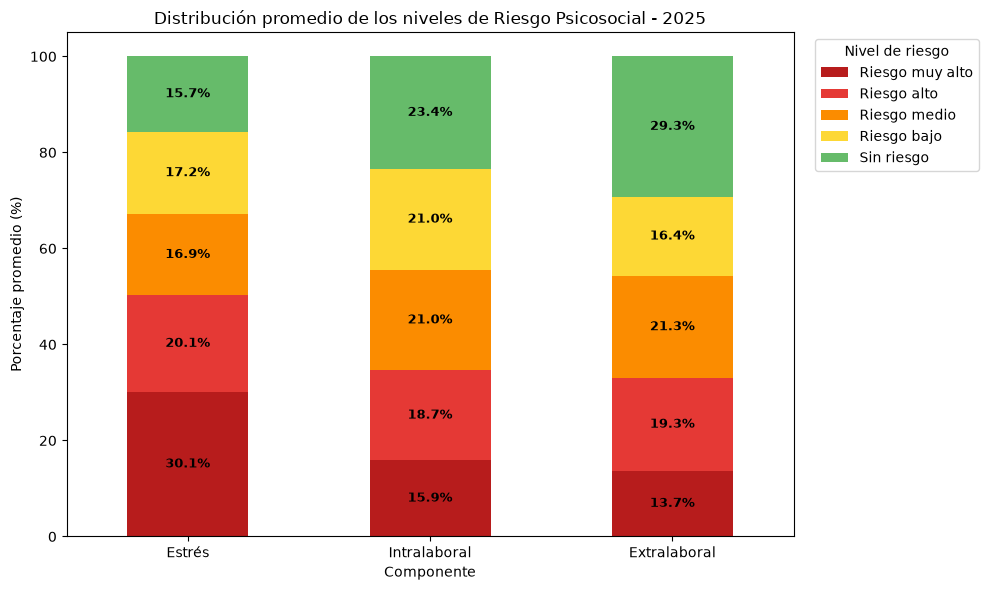

In [20]:
# Gráfico de distribución promedio del Riesgo Psicosocial

colores_riesgo = [
    '#B71C1C',  # Riesgo muy alto
    '#E53935',  # Riesgo alto
    '#FB8C00',  # Riesgo medio
    '#FDD835',  # Riesgo bajo
    '#66BB6A'   # Sin riesgo
]

ax = resumen_riesgo.T.plot(
    kind='bar',
    stacked=True,
    figsize=(10, 6),
    color=colores_riesgo
)

# Agregar etiquetas con los valores dentro de cada segmento
for i, componente in enumerate(resumen_riesgo.columns):
    
    acumulado = 0
    
    for categoria in resumen_riesgo.index:
        
        valor = resumen_riesgo.loc[categoria, componente]
        
        # Solo mostrar etiquetas si el segmento tiene un valor significativo
        if valor >= 3:
            ax.text(
                i,
                acumulado + valor / 2,
                f'{valor:.1f}%',
                ha='center',
                va='center',
                fontsize=9,
                fontweight='bold'
            )
        
        acumulado += valor

plt.title('Distribución promedio de los niveles de Riesgo Psicosocial - 2025')
plt.xlabel('Componente')
plt.ylabel('Porcentaje promedio (%)')
plt.xticks(rotation=0)

plt.legend(
    title='Nivel de riesgo',
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)

plt.tight_layout()
plt.show()

#### 5.5.2 Comparación entre Estrés, Intralaboral y Extralaboral

Para facilitar la comparación entre los componentes del Riesgo Psicosocial, se agrupan las categorías de **Riesgo muy alto** y **Riesgo alto** como niveles de mayor prioridad. Se calcula el porcentaje promedio de unidades que presentan estos niveles de riesgo para Estrés, Intralaboral y Extralaboral. Este indicador permite identificar qué componente concentra una mayor proporción de riesgo elevado y proporciona una primera aproximación para la posterior construcción de indicadores utilizados en el modelo de clusterización.

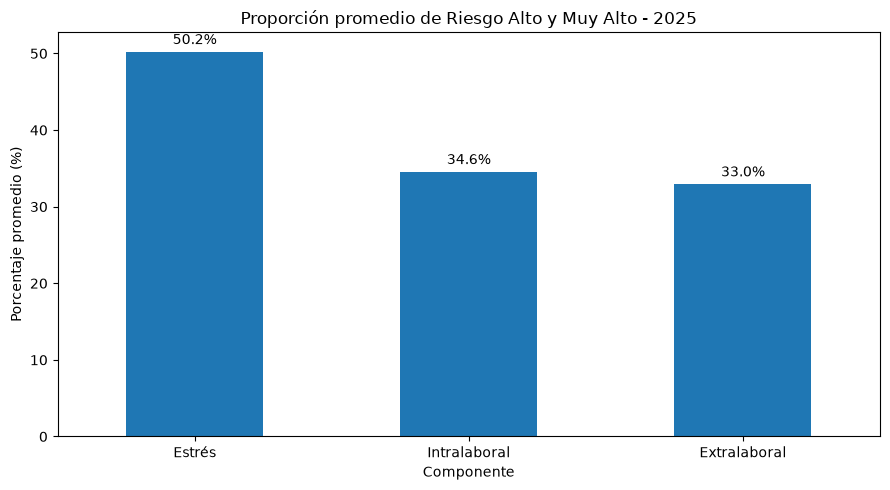

In [21]:
# Visualización comparativa
ax = comparacion_riesgo.T.plot(
    kind='bar',
    figsize=(9, 5),
    legend=False
)

plt.title('Proporción promedio de Riesgo Alto y Muy Alto - 2025')
plt.xlabel('Componente')
plt.ylabel('Porcentaje promedio (%)')
plt.xticks(rotation=0)

# Etiquetas de valores
for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.1f%%',
        padding=3
    )

plt.tight_layout()
plt.show()

#### 5.5.3 Hallazgos principales

El análisis de Riesgo Psicosocial para las 186 unidades de tipo Agencia y PDA evidencia diferencias entre los tres componentes evaluados. La proporción promedio de riesgo alto y muy alto es mayor en **Estrés**, seguido de **Intralaboral** y **Extralaboral**. Esto indica que el componente de Estrés concentra la mayor exposición relativa a niveles elevados de riesgo entre las unidades analizadas. Estos resultados permiten identificar al Estrés como un componente relevante para la caracterización posterior de las oficinas y constituyen un insumo para la construcción de indicadores utilizados en el modelo de clusterización.

### 5.6 Análisis de Evaluación del Desempeño

Se analiza el comportamiento de la Evaluación del Desempeño correspondiente a 2025 para las unidades de tipo Agencia y PDA. El análisis considera los componentes de Objetivo, Competencia y Resultado, con el propósito de identificar diferencias en el desempeño de las unidades y establecer los principales hallazgos que serán considerados posteriormente en la construcción de indicadores para el modelo de clusterización.

#### 5.6.1 Distribución de los resultados de desempeño

Se analiza la distribución de los resultados obtenidos en los componentes de Objetivo, Competencia y Resultado durante 2025. Se calculan medidas descriptivas como promedio, mediana, mínimo y máximo, con el fin de conocer el comportamiento general del desempeño entre las unidades analizadas.

In [22]:
# Identificar variables numéricas de Desempeño correspondientes a 2025
variables_desempeno_2025 = [
    col for col in variables_desempeno
    if '2025' in col
    and 'INTERPRETACION' not in col.upper()
]

print(f"Variables de Desempeño 2025: {len(variables_desempeno_2025)}")

for variable in variables_desempeno_2025:
    print(f"- {variable}")

Variables de Desempeño 2025: 3
- Evaluación del desempeño_AÑO 2025_OBJETIVO
- Evaluación del desempeño_AÑO 2025_COMPETENCIA
- Evaluación del desempeño_AÑO 2025_RESULTADO


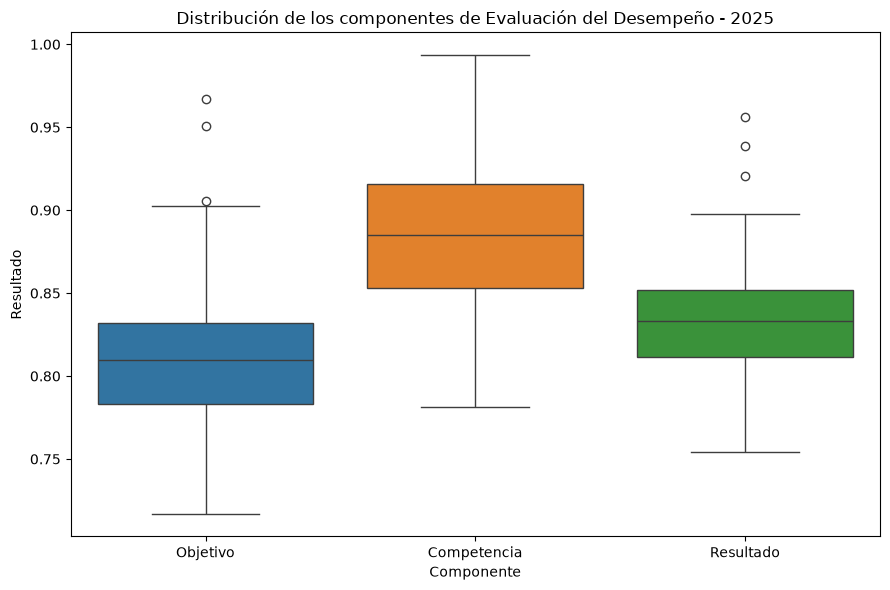

In [23]:
# Preparar datos para visualización
datos_desempeno = df_modelo[variables_desempeno_2025].copy()

# Renombrar columnas para facilitar la lectura
datos_desempeno.columns = ['Objetivo', 'Competencia', 'Resultado']

# Gráfico de distribución
plt.figure(figsize=(9, 6))

sns.boxplot(data=datos_desempeno)

plt.title('Distribución de los componentes de Evaluación del Desempeño - 2025')
plt.xlabel('Componente')
plt.ylabel('Resultado')
plt.tight_layout()
plt.show()

In [24]:
# Calcular promedio de cada componente

promedio_desempeno = (
    datos_desempeno
    .mean()
    .sort_values(ascending=False)
)

promedio_desempeno.round(3)

Competencia    0.882
Resultado      0.832
Objetivo       0.810
dtype: float64

#### 5.6.2 Comparación entre Objetivo, Competencia y Resultado

Se comparan los valores promedio de los tres componentes de la Evaluación del Desempeño para identificar cuál presenta el mayor y menor resultado promedio entre las unidades analizadas. A diferencia del Riesgo Psicosocial, en esta dimensión un resultado más alto representa un mejor desempeño. Esta dirección deberá conservarse durante la preparación de los datos para el modelo de clusterización.

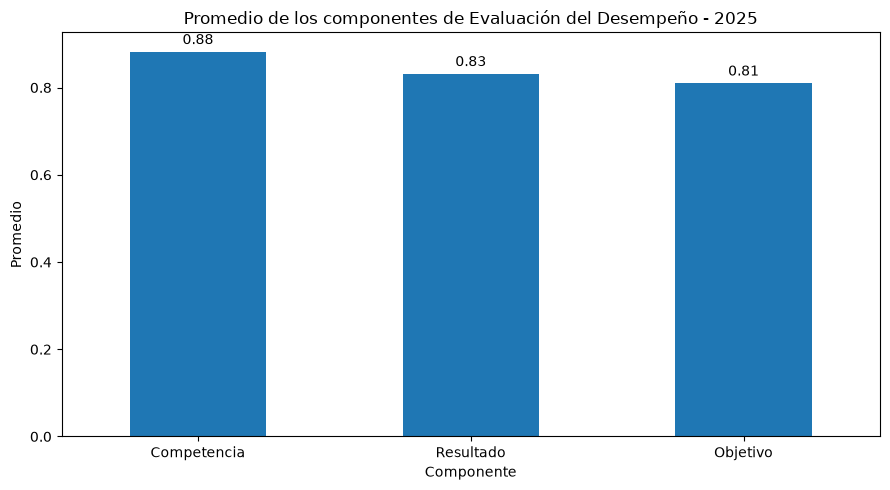

In [25]:
# Gráfico de promedio por componente
ax = promedio_desempeno.plot(
    kind='bar',
    figsize=(9, 5)
)

plt.title('Promedio de los componentes de Evaluación del Desempeño - 2025')
plt.xlabel('Componente')
plt.ylabel('Promedio')
plt.xticks(rotation=0)

# Etiquetas
for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.2f',
        padding=3
    )

plt.tight_layout()
plt.show()

#### 5.6.3 Hallazgos principales

La Evaluación del Desempeño de 2025 presenta un comportamiento favorable entre las unidades analizadas. Se identifican diferencias en los resultados promedio de los componentes de Objetivo, Competencia y Resultado, las cuales permiten caracterizar distintos niveles de desempeño. Los resultados muestran que los componentes de desempeño pueden utilizarse como indicadores diferenciadores entre oficinas. Para el posterior modelo de clusterización se deberá considerar que, a diferencia del Riesgo Psicosocial, un mayor resultado de desempeño representa una condición favorable.

### 5.7 Análisis de Engagement

Se analiza el comportamiento del Engagement durante 2025 en las unidades de tipo Agencia y PDA. El análisis considera los componentes de Ambiente Laboral y Compromiso, con el propósito de identificar diferencias entre las unidades y establecer los principales hallazgos que serán utilizados posteriormente en la construcción de indicadores para el modelo de clusterización.

#### 5.7.1 Distribución de los resultados de Engagement

Se analiza la distribución de los resultados de Ambiente Laboral y Compromiso durante 2025 mediante medidas descriptivas y representaciones gráficas. Este análisis permite identificar el nivel general de Engagement y la dispersión de los resultados entre las unidades analizadas.

Variables de Engagement 2025: 2
- Engagement_AÑO 2025_AMBIENTE LABORAL
- Engagement_AÑO 2025_COMPROMISO


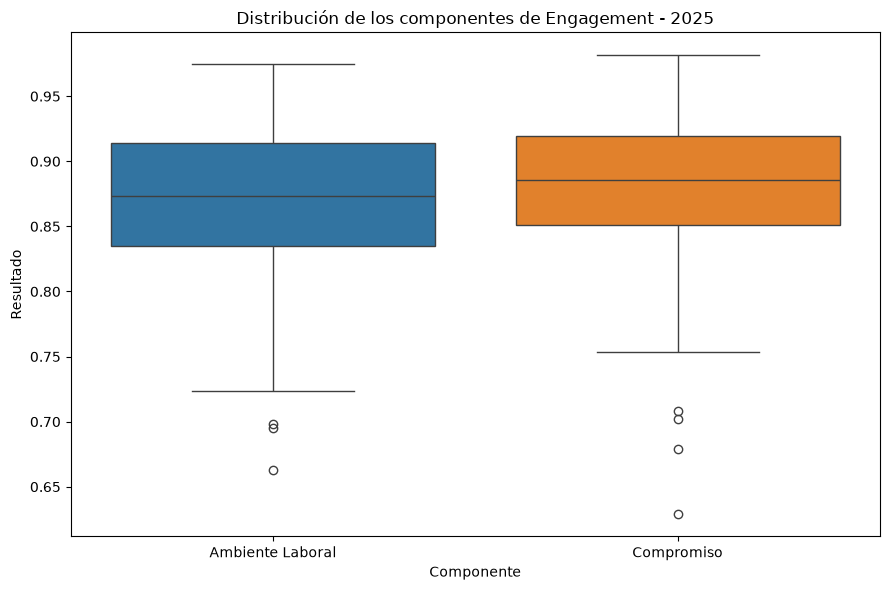

In [26]:
# Identificar variables numéricas de Engagement 2025
variables_engagement_2025 = [
    col for col in variables_engagement
    if '2025' in col
    and 'INTERPRETACION' not in col.upper()
]
print(f"Variables de Engagement 2025: {len(variables_engagement_2025)}")

for variable in variables_engagement_2025:
    print(f"- {variable}")
    
# Preparar datos para visualización
datos_engagement = df_modelo[variables_engagement_2025].copy()
datos_engagement.columns = [
    'Ambiente Laboral',
    'Compromiso'
]

# Gráfico de distribución
plt.figure(figsize=(9, 6))
sns.boxplot(data=datos_engagement)
plt.title('Distribución de los componentes de Engagement - 2025')
plt.xlabel('Componente')
plt.ylabel('Resultado')
plt.tight_layout()
plt.show()

#### 5.7.2 Comparación entre Ambiente Laboral y Compromiso

Se comparan los resultados promedio de Ambiente Laboral y Compromiso para identificar diferencias en el comportamiento de ambos componentes entre las unidades analizadas. En esta dimensión, al igual que en Evaluación del Desempeño, un resultado más alto representa una condición favorable. Por lo tanto, durante la preparación de los datos para el modelo de clusterización, los valores bajos serán interpretados como una mayor vulnerabilidad.

#### 5.7.3 Hallazgos principales

El análisis de Engagement permite identificar el comportamiento de los componentes de Ambiente Laboral y Compromiso entre las unidades analizadas. Ambos componentes presentan información relacionada con la experiencia de los colaboradores y muestran una alta asociación entre sí. Por esta razón, aunque ambos componentes se analizan de manera independiente durante la exploración, posteriormente serán integrados en un único indicador de **Engagement General**, con el propósito de reducir redundancia en el modelo de clusterización.

#### Resumen del proceso de reducción

```text
50 variables numéricas
        ↓
Selección de variables 2025
        ↓
20 variables
        ↓
Agrupación conceptual
        ↓
8 grupos de indicadores

┌─────────────────────────────────────┐
│ 🧠 Riesgo Psicosocial               │
│                                     │
│   ├── Estrés                        │
│   ├── Intralaboral                  │
│   └── Extralaboral                  │
│                                     │
│ 🎯 Evaluación del Desempeño         │
│                                     │
│   ├── Objetivo                      │
│   ├── Competencia                   │
│   └── Resultado                     │
│                                     │
│ ❤️ Engagement                       │
│                                     │
│   ├── Ambiente Laboral              │
│   └── Compromiso                    │
└─────────────────────────────────────┘

### 5.8 Relación entre las dimensiones

Con el propósito de analizar la relación existente entre las tres dimensiones del estudio, se construyen indicadores resumidos para cada componente. Para Riesgo Psicosocial se utiliza la proporción de riesgo alto y muy alto de cada componente. Para Evaluación del Desempeño se conserva el resultado promedio de Objetivo, Competencia y Resultado, mientras que para Engagement se utilizan los resultados de Ambiente Laboral y Compromiso. Estos indicadores permiten reducir la dimensionalidad y analizar las relaciones entre las dimensiones antes de definir las variables que serán utilizadas en el modelo de clusterización.

#### 5.8.1 Construcción de indicadores resumidos

Se construyen ocho indicadores representativos de las tres dimensiones analizadas. Los indicadores de Riesgo Psicosocial representan una condición desfavorable cuando presentan valores altos, mientras que los indicadores de Desempeño y Engagement representan una condición favorable cuando presentan valores altos. Esta diferenciación será considerada posteriormente en la preparación de los datos para el modelo de clusterización.

In [27]:
# Crear DataFrame con los indicadores resumidos
indicadores = pd.DataFrame(index=df_modelo.index)

# --------------------------------------------------
# RIESGO PSICOSOCIAL
# --------------------------------------------------
# Estrés: Riesgo alto + muy alto
indicadores['Riesgo_Estres'] = (
    df_modelo[grupos_riesgo['Estrés']]
    .filter(regex='Riesgo muy alto|Riesgo alto')
    .sum(axis=1)
)
# Intralaboral: Riesgo alto + muy alto
indicadores['Riesgo_Intralaboral'] = (
    df_modelo[grupos_riesgo['Intralaboral']]
    .filter(regex='Riesgo muy alto|Riesgo alto')
    .sum(axis=1)
)
# Extralaboral: Riesgo alto + muy alto
indicadores['Riesgo_Extralaboral'] = (
    df_modelo[grupos_riesgo['Extralaboral']]
    .filter(regex='Riesgo muy alto|Riesgo alto')
    .sum(axis=1)
)

# --------------------------------------------------
# DESEMPEÑO
# --------------------------------------------------
indicadores['Desempeno_Objetivo'] = (
    df_modelo[variables_desempeno_2025]
    .filter(regex='OBJETIVO')
    .iloc[:, 0]
)
indicadores['Desempeno_Competencia'] = (
    df_modelo[variables_desempeno_2025]
    .filter(regex='COMPETENCIA')
    .iloc[:, 0]
)
indicadores['Desempeno_Resultado'] = (
    df_modelo[variables_desempeno_2025]
    .filter(regex='RESULTADO')
    .iloc[:, 0]
)

# --------------------------------------------------
# ENGAGEMENT
# --------------------------------------------------
indicadores['Engagement_Ambiente'] = (
    df_modelo[variables_engagement_2025]
    .filter(regex='AMBIENTE LABORAL')
    .iloc[:, 0]
)
indicadores['Engagement_Compromiso'] = (
    df_modelo[variables_engagement_2025]
    .filter(regex='COMPROMISO')
    .iloc[:, 0]
)

# Visualizar los indicadores
indicadores.head()

,Riesgo_Estres,Riesgo_Intralaboral,Riesgo_Extralaboral,Desempeno_Objetivo,Desempeno_Competencia,Desempeno_Resultado,Engagement_Ambiente,Engagement_Compromiso
1,0.444444,0.444444,0.333333,0.807467,0.847273,0.819409,0.840530,0.867424
2,0.777778,0.444444,0.444444,0.835373,0.865455,0.844397,0.843403,0.892361
3,0.500000,0.000000,0.666667,0.821963,0.867857,0.835731,0.892188,0.885417
4,0.625000,0.000000,0.375000,0.879329,0.879107,0.879262,0.969271,0.963542
5,0.272727,0.272727,0.272727,0.888977,0.887033,0.888394,0.947917,0.934524


#### 5.8.2 Análisis de correlaciones

Se calcula la matriz de correlación entre los ocho indicadores resumidos para identificar relaciones lineales entre los componentes de Riesgo Psicosocial, Evaluación del Desempeño y Engagement. Las correlaciones permiten identificar posibles relaciones entre variables y detectar indicadores altamente relacionados que puedan aportar información redundante al modelo de clusterización.

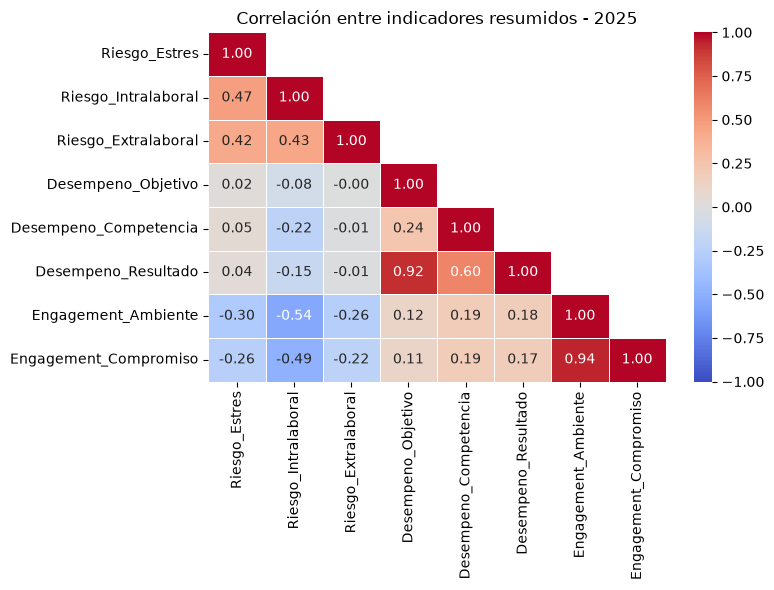

In [28]:
# Matriz de correlación
matriz_correlacion_indicadores = indicadores.corr()

# Crear máscara para ocultar la mitad superior
mascara = np.triu(
    np.ones_like(matriz_correlacion_indicadores, dtype=bool),
    k=1
)

# Visualización de la matriz
plt.figure(figsize=(8, 6))

sns.heatmap(
    matriz_correlacion_indicadores,
    mask=mascara,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5,
    vmin=-1,
    vmax=1
)

plt.title('Correlación entre indicadores resumidos - 2025')
plt.tight_layout()
plt.show()

#### 5.8.3 Identificación de relaciones relevantes

Se identifican las relaciones más fuertes entre los indicadores mediante el coeficiente de correlación de Pearson. Este análisis permite determinar si existen variables con alta asociación que puedan generar redundancia y, por tanto, requerir una revisión antes de incorporarlas al modelo de clusterización.

In [29]:
# Obtener correlaciones entre pares de variables
correlaciones = (
    matriz_correlacion_indicadores
    .where(
        np.triu(
            np.ones(matriz_correlacion_indicadores.shape),
            k=1
        ).astype(bool)
    )
    .stack()
    .reset_index()
)

correlaciones.columns = ['Variable 1', 'Variable 2', 'Correlación']

# Agregar valor absoluto para ordenar por fuerza de relación
correlaciones['Abs_Correlación'] = (
    correlaciones['Correlación'].abs()
)

correlaciones = (
    correlaciones
    .sort_values('Abs_Correlación', ascending=False)
    .drop(columns='Abs_Correlación')
)

correlaciones.round(3)

,Variable 1,Variable 2,Correlación
55,Engagement_Ambiente,Engagement_Compromiso,0.940
29,Desempeno_Objetivo,Desempeno_Resultado,0.919
37,Desempeno_Competencia,Desempeno_Resultado,0.596
14,Riesgo_Intralaboral,Engagement_Ambiente,-0.541
15,Riesgo_Intralaboral,Engagement_Compromiso,-0.489
...,...,...,...
59,Engagement_Compromiso,Desempeno_Objetivo,NaN
60,Engagement_Compromiso,Desempeno_Competencia,NaN
61,Engagement_Compromiso,Desempeno_Resultado,NaN
62,Engagement_Compromiso,Engagement_Ambiente,NaN


In [30]:
# Correlaciones fuertes
correlaciones_fuertes = correlaciones[
    correlaciones['Correlación'].abs() >= 0.70
]

correlaciones_fuertes.round(3)

,Variable 1,Variable 2,Correlación
55,Engagement_Ambiente,Engagement_Compromiso,0.940
29,Desempeno_Objetivo,Desempeno_Resultado,0.919


#### 5.8.3 Reducción de indicadores

El análisis de correlaciones permitió identificar relaciones fuertes entre algunos indicadores que aportan información similar. Se identificó una correlación de **0.94 entre Ambiente Laboral y Compromiso**, por lo que ambos indicadores se integran en un único indicador de Engagement. De igual manera, se encontró una correlación de **0.92 entre Objetivo y Resultado** dentro de la Evaluación del Desempeño. Por esta razón, ambos componentes se integran en un indicador general de Desempeño, mientras que Competencia se conserva como un indicador independiente.

Los tres componentes de Riesgo Psicosocial presentan correlaciones moderadas, por lo que se mantienen separados para conservar las diferencias entre Estrés, Intralaboral y Extralaboral. Como resultado, se reduce el conjunto de análisis de **8 a 6 indicadores**, disminuyendo la redundancia sin perder las principales dimensiones del problema.

#### Reducción final de indicadores

```text
8 indicadores
       ↓
Análisis de correlaciones
       ↓
Identificación de alta redundancia
       ↓
6 indicadores finales


┌─────────────────────────────────────┐
│ 🧠 RIESGO PSICOSOCIAL              │
│                                     │
│   ├── Riesgo Estrés                 │
│   ├── Riesgo Intralaboral           │
│   └── Riesgo Extralaboral           │
│                                     │
│ 🎯 DESEMPEÑO                        │
│                                     │
│   ├── Desempeño General             │
│   └── Competencia                   │
│                                     │
│ ❤️ ENGAGEMENT                       │
│                                     │
│   └── Engagement General             │
└─────────────────────────────────────┘

In [31]:
# ============================================================
# CONSTRUCCIÓN DE LOS 6 INDICADORES FINALES
# ============================================================
indicadores_6 = pd.DataFrame(index=df_modelo.index)
# ------------------------------------------------------------
# 1. RIESGO PSICOSOCIAL
# ------------------------------------------------------------
indicadores_6['Riesgo_Estres'] = indicadores['Riesgo_Estres']
indicadores_6['Riesgo_Intralaboral'] = indicadores['Riesgo_Intralaboral']
indicadores_6['Riesgo_Extralaboral'] = indicadores['Riesgo_Extralaboral']
# ------------------------------------------------------------
# 2. DESEMPEÑO
# ------------------------------------------------------------
# Objetivo y Resultado presentan alta correlación (0.92),
# por lo que se integran en un indicador general.
indicadores_6['Desempeno_General'] = (
    indicadores[
        ['Desempeno_Objetivo', 'Desempeno_Resultado']
    ]
    .mean(axis=1)
)
# Competencia se conserva como indicador independiente
indicadores_6['Desempeno_Competencia'] = (
    indicadores['Desempeno_Competencia']
)
# ------------------------------------------------------------
# 3. ENGAGEMENT
# ------------------------------------------------------------
# Ambiente Laboral y Compromiso presentan alta correlación (0.94),
# por lo que se integran en un único indicador.
indicadores_6['Engagement_General'] = (
    indicadores[
        ['Engagement_Ambiente', 'Engagement_Compromiso']
    ]
    .mean(axis=1)
)

# Estadísticas descriptivas de los 6 indicadores
indicadores_6.describe().T.round(3)

,count,mean,std,min,25%,50%,75%,max
Riesgo_Estres,186.0,0.502,0.162,0.100,0.400,0.500,0.624,0.875
Riesgo_Intralaboral,186.0,0.346,0.184,0.000,0.223,0.333,0.467,0.778
Riesgo_Extralaboral,186.0,0.330,0.157,0.000,0.215,0.312,0.429,0.875
Desempeno_General,186.0,0.821,0.036,0.742,0.797,0.820,0.841,0.962
Desempeno_Competencia,186.0,0.882,0.045,0.781,0.853,0.885,0.916,0.993
Engagement_General,186.0,0.873,0.058,0.664,0.845,0.879,0.917,0.978


### 5.9 Hallazgos principales

El análisis exploratorio permitió caracterizar las unidades de tipo Agencia y PDA y establecer una estructura de variables adecuada para el posterior modelamiento no supervisado. Inicialmente se identificaron **50 variables numéricas**. Debido a que el conjunto de datos contiene información de diferentes periodos, se seleccionaron las variables correspondientes a **2025**, obteniendo 20 variables relacionadas con Riesgo Psicosocial, Evaluación del Desempeño y Engagement.

El análisis conceptual permitió organizar estas variables en ocho indicadores. Posteriormente, el análisis de correlaciones identificó relaciones altamente significativas entre algunos componentes, especialmente entre **Ambiente Laboral y Compromiso (r = 0.94)** y entre **Objetivo y Resultado (r = 0.92)**. Con base en estas relaciones, se redujo el conjunto de variables a **seis indicadores finales**, buscando disminuir la redundancia y conservar la información relevante para diferenciar los perfiles de las oficinas.

Los indicadores seleccionados son:

- **Riesgo Psicosocial:** Riesgo Estrés, Riesgo Intralaboral y Riesgo Extralaboral.
- **Desempeño:** Desempeño General y Competencia.
- **Engagement:** Engagement General.

Para la interpretación de los indicadores se considera la dirección de cada dimensión: en Riesgo Psicosocial, valores altos representan una condición desfavorable; mientras que en Desempeño y Engagement, valores altos representan una condición favorable. De esta manera, el análisis exploratorio permite pasar de un conjunto inicial de alta dimensionalidad a una estructura de seis indicadores interpretables, que serán evaluados y preparados para el modelo de clusterización.

## 6. 🧮 Modelamiento no supervisado: Clusterización de oficinas

### 6.1 Objetivo y selección de variables

El objetivo de esta etapa es construir un modelo de **clusterización no supervisado** que permita agrupar las oficinas según patrones similares en Riesgo Psicosocial, Evaluación del Desempeño y Engagement. Se utilizará el algoritmo **K-Means**, evaluando diferentes cantidades de grupos y priorizando la comparación entre soluciones de **4 y 5 clusters**. El modelo buscará identificar perfiles diferenciados de oficinas, sin establecer previamente categorías de vulnerabilidad. Posteriormente, estos perfiles serán interpretados de acuerdo con sus características de riesgo, desempeño y engagement.

Como resultado del análisis exploratorio, se seleccionaron seis indicadores finales:

- **Riesgo Psicosocial:** Riesgo Estrés, Riesgo Intralaboral y Riesgo Extralaboral.
- **Desempeño:** Desempeño General y Competencia.
- **Engagement:** Engagement General.

Estos indicadores constituyen las variables de entrada iniciales para el modelo de clusterización.

### 6.2 Preparación de los datos

Para aplicar el algoritmo K-Means es necesario preparar los indicadores seleccionados en la etapa anterior. El conjunto de modelamiento estará conformado por los seis indicadores definidos para las oficinas de tipo Agencia y PDA. En esta etapa los indicadores serán estandarizados mediante `StandardScaler`, con el objetivo de llevarlos a una escala comparable y evitar que una variable tenga mayor influencia en el cálculo de las distancias debido únicamente a su magnitud. La dirección conceptual de los indicadores también será considerada durante la interpretación de los resultados: valores altos de Riesgo Psicosocial representan mayor exposición al riesgo, mientras que valores altos de Desempeño y Engagement representan mejores condiciones.

In [32]:
# Copia de los indicadores seleccionados para el modelamiento

df_cluster = indicadores_6.copy()

# Agregar información de identificación de las oficinas
df_cluster['CODIGO UNIDAD'] = df_modelo['CODIGO UNIDAD']
df_cluster['REGIONAL'] = df_modelo['REGIONAL']
df_cluster['TIPO'] = df_modelo['TIPO']

# Visualizar estructura
df_cluster.head()

,Riesgo_Estres,Riesgo_Intralaboral,Riesgo_Extralaboral,Desempeno_General,Desempeno_Competencia,Engagement_General,CODIGO UNIDAD,REGIONAL,TIPO
1,0.444444,0.444444,0.333333,0.813438,0.847273,0.853977,A411243,CAUCA,PDA
2,0.777778,0.444444,0.444444,0.839885,0.865455,0.867882,A411242,CAUCA,PDA
3,0.500000,0.000000,0.666667,0.828847,0.867857,0.888802,A411221,CAUCA,PDA
4,0.625000,0.000000,0.375000,0.879296,0.879107,0.966406,A411241,CAUCA,PDA
5,0.272727,0.272727,0.272727,0.888685,0.887033,0.941220,A411231,CAUCA,PDA


In [33]:
# Validar cantidad de oficinas por tipo
df_cluster['TIPO'].value_counts()

TIPO
Agencia    121
PDA         65
Name: count, dtype: int64

#### 6.2.1 Tratamiento de valores faltantes

Los valores faltantes ya fueron identificados durante el análisis exploratorio. En esta etapa se aplica el tratamiento definido para las variables que ingresarán al modelo, utilizando la mediana de cada indicador cuando sea necesario.


In [34]:
# Variables que ingresarán al modelo
variables_cluster = [
    'Riesgo_Estres',
    'Riesgo_Intralaboral',
    'Riesgo_Extralaboral',
    'Desempeno_General',
    'Desempeno_Competencia',
    'Engagement_General'
]

# Aplicar imputación por mediana
for col in variables_cluster:
    df_cluster[col] = df_cluster[col].fillna(df_cluster[col].median())

# Verificación final de valores faltantes
print("Valores faltantes después del tratamiento:")
print(df_cluster[variables_cluster].isna().sum())


Valores faltantes después del tratamiento:
Riesgo_Estres            0
Riesgo_Intralaboral      0
Riesgo_Extralaboral      0
Desempeno_General        0
Desempeno_Competencia    0
Engagement_General       0
dtype: int64


#### 6.2.2 Estandarización de los indicadores

Los seis indicadores se estandarizan mediante `StandardScaler` para llevarlos a una escala comparable antes de aplicar K-Means.


In [35]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_cluster = scaler.fit_transform(df_cluster[variables_cluster])

X_cluster = pd.DataFrame(
    X_cluster,
    columns=variables_cluster,
    index=df_cluster.index
)

# Validar la estandarización
resumen_estandarizacion = pd.DataFrame({
    'Media': X_cluster.mean(),
    'Desviación estándar': X_cluster.std()
})

resumen_estandarizacion.round(3)


,Media,Desviación estándar
Riesgo_Estres,-0.0,1.003
Riesgo_Intralaboral,-0.0,1.003
Riesgo_Extralaboral,-0.0,1.003
Desempeno_General,-0.0,1.003
Desempeno_Competencia,0.0,1.003
Engagement_General,0.0,1.003
